# Figure 4: scIDiff Regulatory Grammar Analysis

**Simplified notebook for external users**

This notebook generates Figure 4 for the scIDiff manuscript, showing:
- Drift field dynamics
- Dynamical instability profile
- Regulatory archetype activations
- Archetype coordination patterns
- Top genes ranked by instability

**Dataset:** Paul et al. (2015) mouse hematopoiesis data

**Runtime:** ~2-3 minutes on standard laptop

---

```

## Step 1: Import Libraries

In [1]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec
from scipy.interpolate import griddata
from scipy.spatial import cKDTree
from sklearn.decomposition import NMF

# Single-cell analysis
import scanpy as sc

import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Configure plotting for Nature Computational Science
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 7,
    'axes.labelsize': 8,
    'axes.titlesize': 9,
    'xtick.labelsize': 6,
    'ytick.labelsize': 6,
    'legend.fontsize': 6,
    'figure.dpi': 150,
    'savefig.dpi': 600,
    'axes.linewidth': 0.75,
})

print('✓ Libraries imported successfully')

✓ Libraries imported successfully


## Step 2: Load and Preprocess Data

We'll load the Paul15 hematopoiesis dataset and perform standard preprocessing.

In [2]:
# Load Paul15 dataset
print('Loading Paul15 dataset...')
adata = sc.datasets.paul15() # ONLINE USE
# adata = sc.read_h5ad("IMPORTED DATASET HERE") # OFFLINE USE
print(f'Loaded: {adata.n_obs} cells × {adata.n_vars} genes')

# Standard preprocessing pipeline
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=2000)
adata_hvg = adata[:, adata.var.highly_variable].copy()

# PCA for dimensionality reduction
sc.pp.scale(adata_hvg, max_value=10)
sc.tl.pca(adata_hvg, n_comps=30)

# Compute neighbors for downstream analysis
sc.pp.neighbors(adata_hvg, n_neighbors=30, n_pcs=30)
sc.tl.umap(adata_hvg)

# Compute pseudotime using diffusion pseudotime
sc.tl.diffmap(adata_hvg, n_comps=15)
adata_hvg.uns['iroot'] = np.flatnonzero(adata_hvg.obs['paul15_clusters'] == '1Ery')[0]
sc.tl.dpt(adata_hvg)

# Assign lineages (Erythroid vs Myeloid)
lineage = []
for cluster in adata_hvg.obs['paul15_clusters']:
    if any(x in str(cluster) for x in ['Ery', '1', '2', '3', '4', '5', '6', '7']):
        lineage.append('Erythroid')
    else:
        lineage.append('Myeloid')
adata_hvg.obs['lineage'] = lineage

print(f'\n✓ Preprocessing complete')
print(f'  Using {adata_hvg.n_vars} highly variable genes')
print(f'  PCA variance explained: {adata_hvg.uns["pca"]["variance_ratio"][:30].sum():.1%}')
print(f'  Erythroid cells: {sum(np.array(lineage)=="Erythroid")}')
print(f'  Myeloid cells: {sum(np.array(lineage)=="Myeloid")}')

Loading Paul15 dataset...
Loaded: 2730 cells × 3451 genes

✓ Preprocessing complete
  Using 2000 highly variable genes
  PCA variance explained: 15.4%
  Erythroid cells: 2599
  Myeloid cells: 131


## Step 3: Estimate Drift Field

We estimate the drift field using k-nearest neighbors in PCA space.

In [3]:
def estimate_drift_field(X, pseudotime, k=30):
    """
    Estimate drift field using k-NN in PCA space.
    
    Parameters:
    -----------
    X : array (n_cells, n_dims)
        PCA coordinates
    pseudotime : array (n_cells,)
        Pseudotime values
    k : int
        Number of nearest neighbors
    
    Returns:
    --------
    drift : array (n_cells, n_dims)
        Estimated drift vectors
    """
    tree = cKDTree(X)
    drift = np.zeros_like(X)
    
    for i in range(len(X)):
        # Find k nearest neighbors
        _, neighbors = tree.query(X[i], k=k+1)
        neighbors = neighbors[1:]  # Exclude self
        
        # Weight by pseudotime difference (forward direction)
        pt_diff = pseudotime[neighbors] - pseudotime[i]
        weights = np.maximum(pt_diff, 0)
        
        if weights.sum() > 0:
            weights = weights / weights.sum()
            # Weighted average direction
            target = (X[neighbors].T @ weights)
            drift[i] = target - X[i]
    
    return drift

# Extract PCA coordinates and pseudotime
# X_pca = adata_hvg.obsm['X_pca'][:, :30]
X_pca = adata_hvg.obsm['X_diffmap'][:, :30]
pseudotime = adata_hvg.obs['dpt_pseudotime'].values

# Estimate drift field
print('Estimating drift field...')
drift = estimate_drift_field(X_pca, pseudotime, k=30)

print(f'✓ Drift field estimated')
print(f'  Mean drift magnitude: {np.linalg.norm(drift, axis=1).mean():.4f}')

Estimating drift field...
✓ Drift field estimated
  Mean drift magnitude: 0.0147


## Step 4: Compute Jacobian Operators

We compute time-resolved Jacobian matrices using finite differences.

In [4]:
def compute_jacobians(X, drift, pseudotime, n_time=80, epsilon=0.01):
    """
    Compute time-resolved Jacobian matrices.
    
    Parameters:
    -----------
    X : array (n_cells, n_dims)
        PCA coordinates
    drift : array (n_cells, n_dims)
        Drift vectors
    pseudotime : array (n_cells,)
        Pseudotime values
    n_time : int
        Number of time points
    epsilon : float
        Perturbation size for finite differences
    
    Returns:
    --------
    jacobians : array (n_time, n_dims, n_dims)
        Jacobian matrices
    time_points : array (n_time,)
        Time points
    """
    n_dims = X.shape[1]
    time_points = np.linspace(pseudotime.min(), pseudotime.max(), n_time)
    jacobians = []
    
    tree = cKDTree(X)
    
    for t in time_points:
        # Find cells near this time point
        time_mask = np.abs(pseudotime - t) < 0.1
        
        if time_mask.sum() > 5:
            # Use representative cell
            idx = np.where(time_mask)[0][len(np.where(time_mask)[0])//2]
            x0 = X[idx]
            
            # Compute Jacobian using finite differences
            J = np.zeros((n_dims, n_dims))
            
            for i in range(n_dims):
                # Perturb in dimension i
                x_plus = x0.copy()
                x_plus[i] += epsilon
                
                x_minus = x0.copy()
                x_minus[i] -= epsilon
                
                # Find nearest neighbors and interpolate drift
                _, idx_plus = tree.query(x_plus, k=5)
                _, idx_minus = tree.query(x_minus, k=5)
                
                drift_plus = drift[idx_plus].mean(axis=0)
                drift_minus = drift[idx_minus].mean(axis=0)
                
                # Finite difference
                J[:, i] = (drift_plus - drift_minus) / (2 * epsilon)
            
            jacobians.append(J)
        else:
            # Not enough cells, use zero matrix
            jacobians.append(np.zeros((n_dims, n_dims)))
    
    return np.array(jacobians), time_points

print('Computing Jacobian operators...')
jacobians, time_points = compute_jacobians(X_pca, drift, pseudotime, n_time=80)

# Compute eigenvalues and instability
eigenvalues = np.array([np.linalg.eigvals(J) for J in jacobians])
instability = np.max(np.real(eigenvalues), axis=1)

print(f'✓ Computed {len(jacobians)} Jacobian matrices')
print(f'  Max instability: {instability.max():.4f}')
print(f'  Peak at pseudotime: {time_points[np.argmax(instability)]:.3f}')

Computing Jacobian operators...
✓ Computed 80 Jacobian matrices
  Max instability: 0.3918
  Peak at pseudotime: 0.759


## Step 5: Decompose into Regulatory Archetypes

We use Non-negative Matrix Factorization (NMF) to identify regulatory archetypes.

In [5]:
def decompose_archetypes(jacobians, n_archetypes=5):
    """
    Decompose Jacobians into regulatory archetypes using NMF.
    
    Parameters:
    -----------
    jacobians : array (n_time, n_dims, n_dims)
        Jacobian matrices
    n_archetypes : int
        Number of archetypes
    
    Returns:
    --------
    activations : array (n_time, n_archetypes)
        Archetype activation weights
    patterns : array (n_archetypes, n_dims, n_dims)
        Archetype patterns
    """
    n_time, n_dims, _ = jacobians.shape
    
    # Flatten Jacobians
    J_flat = jacobians.reshape(n_time, n_dims * n_dims)
    
    # Make non-negative by shifting
    J_flat_pos = J_flat - J_flat.min() + 1e-10
    
    # Apply NMF
    nmf = NMF(n_components=n_archetypes, init='nndsvda', random_state=42, max_iter=500)
    activations = nmf.fit_transform(J_flat_pos)
    patterns = nmf.components_.reshape(n_archetypes, n_dims, n_dims)
    
    # Normalize activations
    activations = activations / (activations.sum(axis=1, keepdims=True) + 1e-10)
    
    return activations, patterns

print('Decomposing into regulatory archetypes...')
n_archetypes = 5
activations, patterns = decompose_archetypes(jacobians, n_archetypes=n_archetypes)

# Compute correlation matrix for coordination patterns
corr_matrix = np.corrcoef(activations.T)

# Count coordination patterns
sequential = sum(1 for i in range(n_archetypes) 
                for j in range(i+1, n_archetypes) 
                if corr_matrix[i, j] < -0.3)
concurrent = sum(1 for i in range(n_archetypes) 
                for j in range(i+1, n_archetypes) 
                if corr_matrix[i, j] > 0.3)

print(f'✓ Identified {n_archetypes} regulatory archetypes')
print(f'  Sequential patterns: {sequential}')
print(f'  Concurrent patterns: {concurrent}')

Decomposing into regulatory archetypes...
✓ Identified 5 regulatory archetypes
  Sequential patterns: 7
  Concurrent patterns: 2


## Step 6: Rank Genes by Instability

We rank genes based on their contribution to dynamical instability.

In [6]:
def rank_genes(adata_hvg, eigenvalues, time_points):
    """
    Rank genes by their contribution to instability.
    
    Parameters:
    -----------
    adata_hvg : AnnData
        Annotated data object with PCA
    eigenvalues : array (n_time, n_dims)
        Eigenvalues at each time point
    time_points : array (n_time,)
        Time points
    
    Returns:
    --------
    gene_ranking : DataFrame
        Genes ranked by instability score
    """
    # Get PCA components
    pca_components = adata_hvg.varm['PCs'][:, :30]
    gene_names = adata_hvg.var_names.tolist()
    
    # Compute gene scores
    gene_scores = np.zeros(len(gene_names))
    
    for t_idx in range(len(time_points)):
        real_eigvals = np.real(eigenvalues[t_idx])
        
        # Focus on unstable modes
        if np.any(real_eigvals > 0):
            unstable_indices = np.where(real_eigvals > 0)[0]
            
            for idx in unstable_indices:
                # Gene loading from PCA
                gene_loading = np.abs(pca_components[:, idx])
                gene_scores += gene_loading * real_eigvals[idx]
    
    # Normalize
    gene_scores = gene_scores / (gene_scores.max() + 1e-10)
    
    # Create ranking dataframe
    gene_ranking = pd.DataFrame({
        'gene': gene_names,
        'instability_score': gene_scores
    }).sort_values('instability_score', ascending=False)
    
    return gene_ranking

print('Ranking genes by instability...')
gene_ranking = rank_genes(adata_hvg, eigenvalues, time_points)

print(f'\nTop 15 genes by instability:')
print(gene_ranking.head(15).to_string(index=False))

# Check known regulators
known_regulators = ['Gata1', 'Gata2', 'Spi1', 'Cebpa', 'Klf1', 'Tal1']
print(f'\nKnown hematopoietic regulator rankings:')
for gene in known_regulators:
    if gene in gene_ranking['gene'].values:
        rank = gene_ranking[gene_ranking['gene'] == gene].index[0] + 1
        score = gene_ranking[gene_ranking['gene'] == gene]['instability_score'].values[0]
        print(f'  {gene}: rank {rank}/{len(gene_ranking)}, score {score:.4f}')

Ranking genes by instability...

Top 15 genes by instability:
   gene  instability_score
  H2-Aa           1.000000
 H2-Eb1           0.970186
   Cd74           0.963379
  Plbd1           0.925747
 Lgals3           0.845764
   Ccl5           0.799448
    Id2           0.783897
   Irf8           0.769203
 H2-Ab1           0.748793
   Ctsw           0.742590
   NAAA           0.713616
Pglyrp1           0.693358
  Ifi30           0.693044
   Cd63           0.686295
  Cebpe           0.667038

Known hematopoietic regulator rankings:
  Gata1: rank 721/2000, score 0.1566
  Gata2: rank 722/2000, score 0.4262
  Cebpa: rank 375/2000, score 0.2198
  Klf1: rank 982/2000, score 0.1576
  Tal1: rank 1735/2000, score 0.1514


## Step 7: Generate Figure 4 with and without Titles

Create publication-quality figure with all panels.

Generating Figure 4 (w/ titles)...

✓ Figure 4 saved:
  PNG: ../Figures/Figure4_scIDiff.png
  PDF: ../Figures/Figure4_scIDiff.pdf


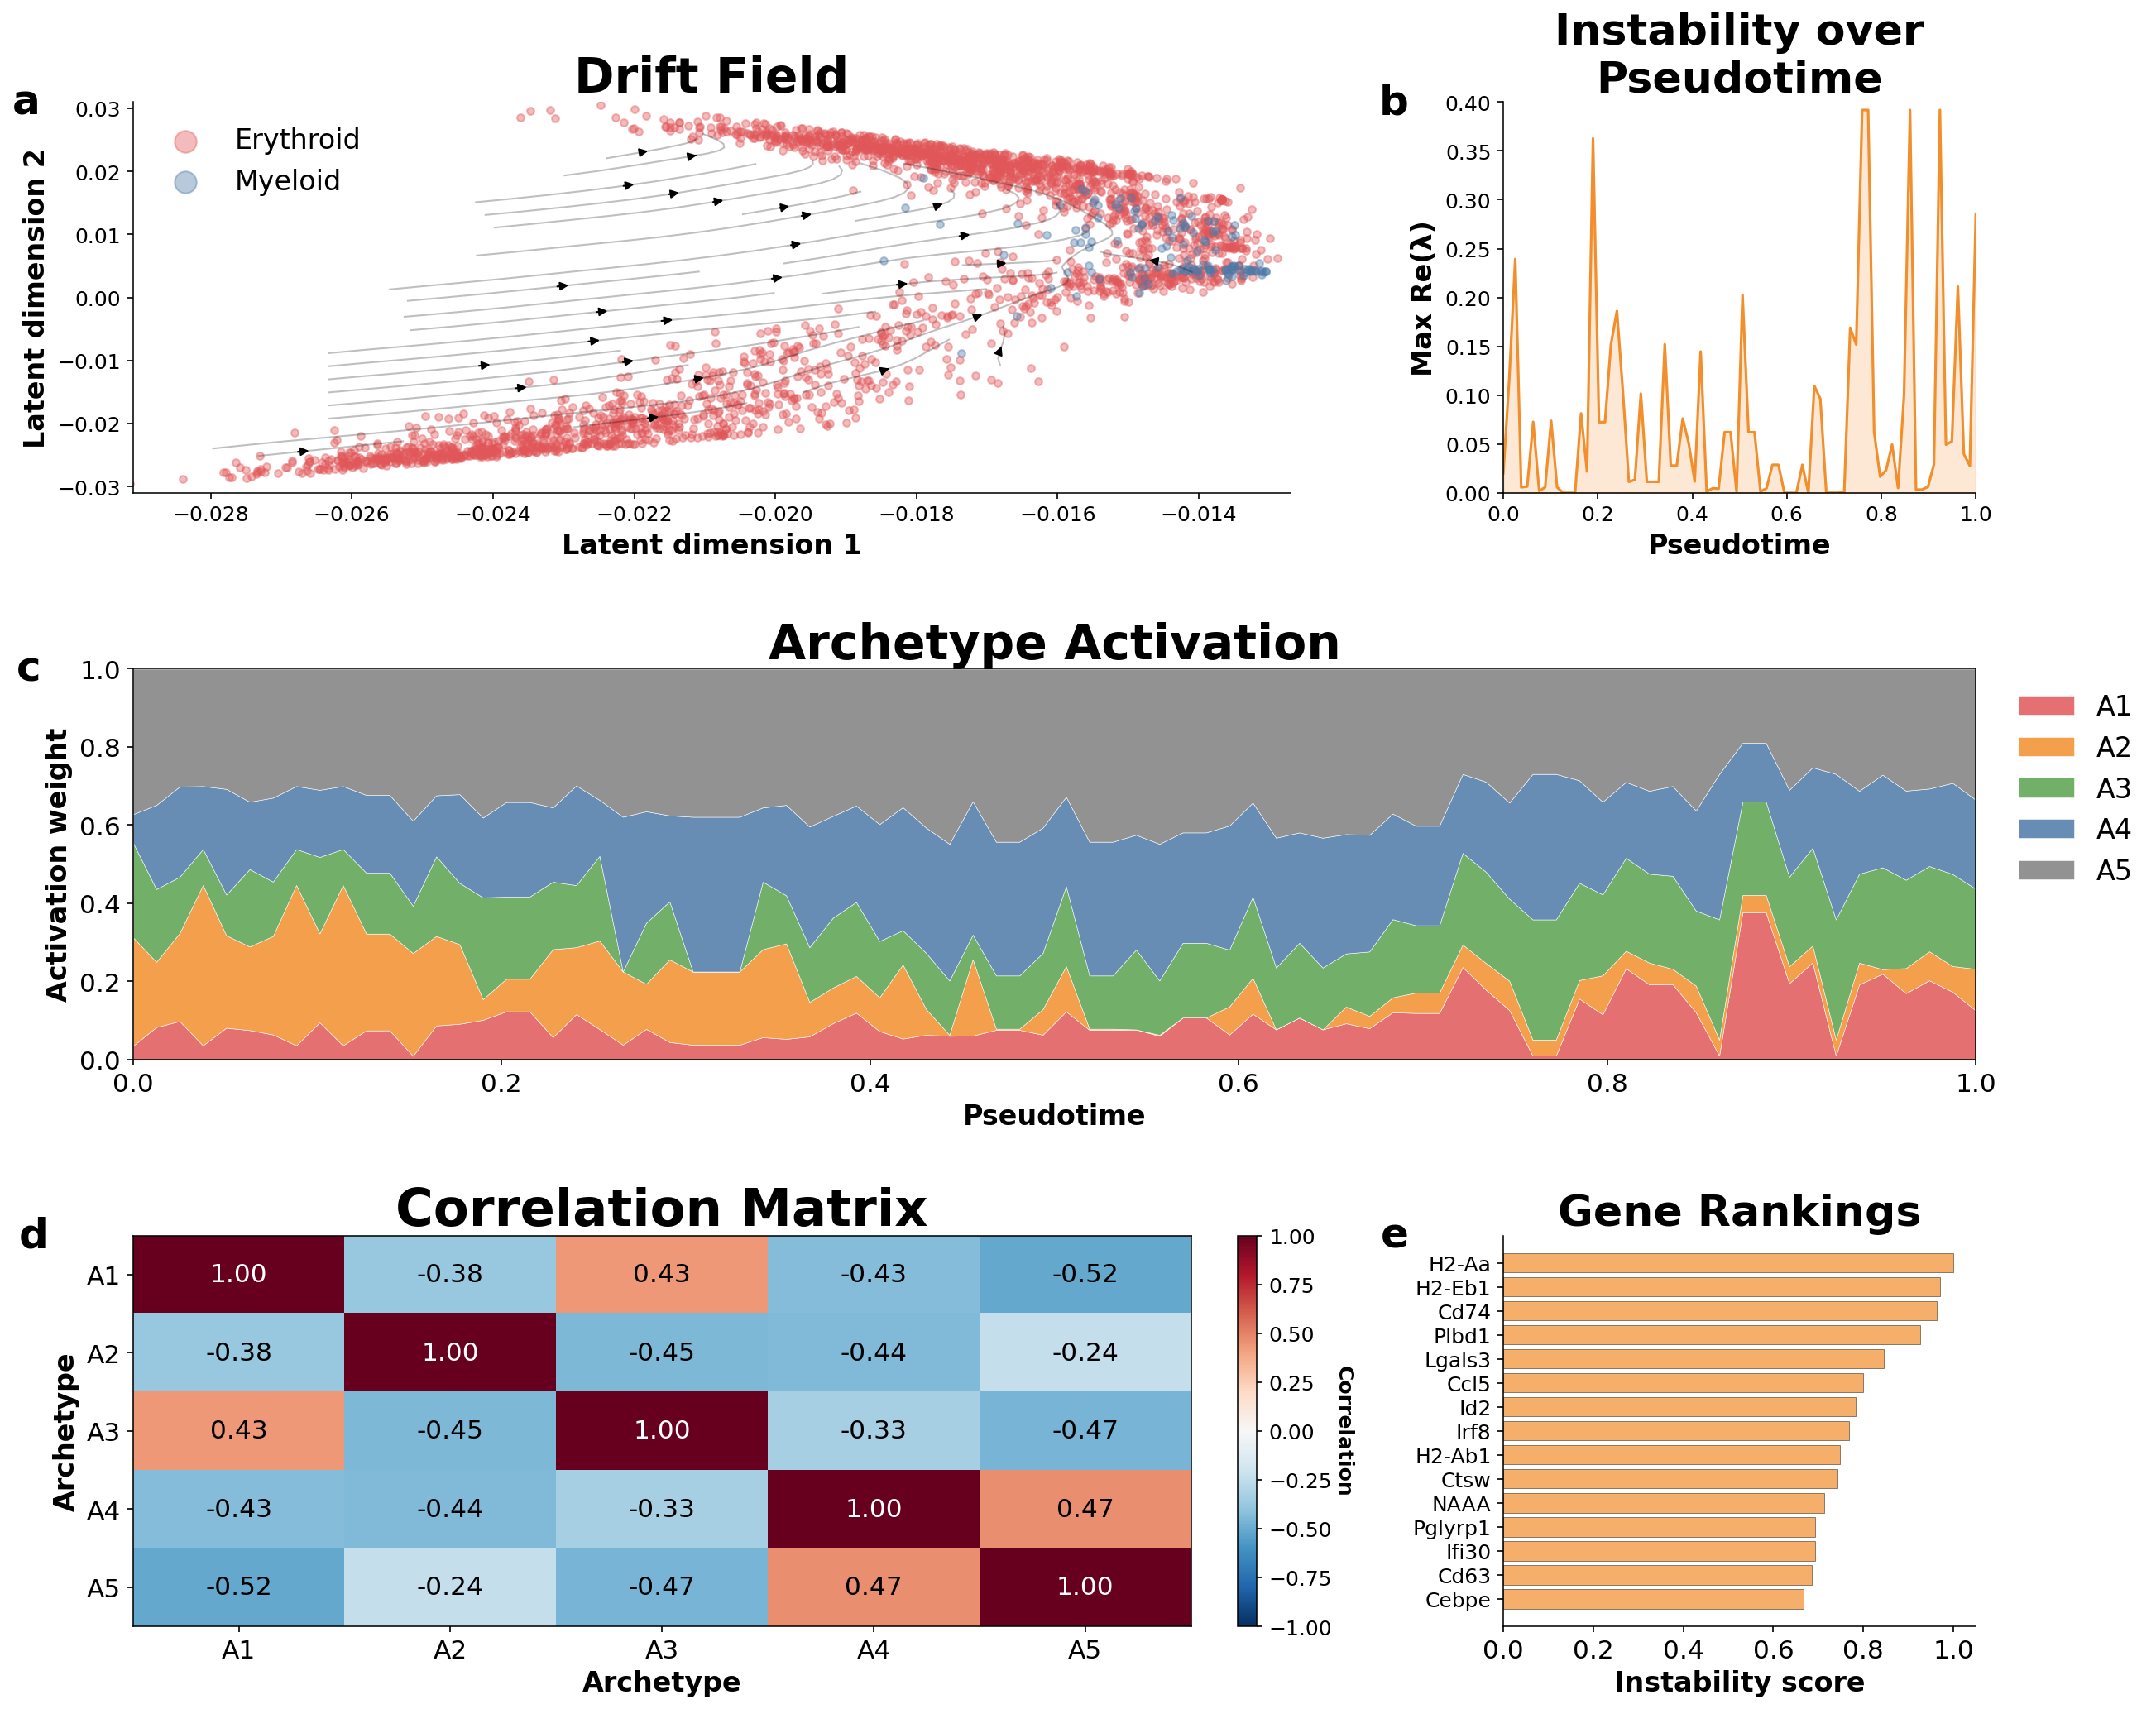

In [7]:
print('Generating Figure 4 (w/ titles)...')

# Color palette
COLORS = {
    'erythroid': '#E15759',
    'myeloid': '#4E79A7',
    'branch': '#F28E2B',
    'archetype1': '#E15759',
    'archetype2': '#F28E2B',
    'archetype3': '#59A14F',
    'archetype4': '#4E79A7',
    'archetype5': '#7F7F7F'
}

# Create figure
fig = plt.figure(figsize=(16.5, 13.5))
gs = GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.45,
              left=0.07, right=0.97, top=0.96, bottom=0.05)

# Panel a: Drift field
ax_a = fig.add_subplot(gs[0, :2])
for lin in ['Erythroid', 'Myeloid']:
    mask = np.array(lineage) == lin
    color = COLORS['erythroid'] if lin == 'Erythroid' else COLORS['myeloid']
    ax_a.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=color, s=18, alpha=0.4, label=lin, rasterized=True)

# Add streamlines
n_grid = 15
x_min, x_max = X_pca[:, 0].min(), X_pca[:, 0].max()
y_min, y_max = X_pca[:, 1].min(), X_pca[:, 1].max()
x_grid = np.linspace(x_min, x_max, n_grid)
y_grid = np.linspace(y_min, y_max, n_grid)

U = griddata(X_pca[:, :2], drift[:, 0], (x_grid[None, :], y_grid[:, None]), method='linear')
V = griddata(X_pca[:, :2], drift[:, 1], (x_grid[None, :], y_grid[:, None]), method='linear')

strm = ax_a.streamplot(x_grid, y_grid, U, V, color='black', linewidth=1, density=1.0)
strm.lines.set_alpha(0.25)

ax_a.set_xlabel('Latent dimension 1', fontsize=16, fontweight='bold')
ax_a.set_ylabel('Latent dimension 2', fontsize=16, fontweight='bold')
ax_a.set_xlim(-0.0291, -0.0127) 
ax_a.set_ylim(-0.031, 0.031)
ax_a.tick_params(axis='both', labelsize=12)
ax_a.set_title('Drift Field', fontweight='bold', loc='center', fontsize=28)
ax_a.legend(frameon=False, fontsize=16, markerscale=3) 
ax_a.spines['top'].set_visible(False)
ax_a.spines['right'].set_visible(False)

# Panel b: Instability
ax_b = fig.add_subplot(gs[0, 2])
ax_b.plot(time_points, instability, color=COLORS['branch'], linewidth=1.5)
ax_b.fill_between(time_points, 0, instability, alpha=0.2, color=COLORS['branch'])
ax_b.set_xlabel('Pseudotime', fontsize=16, fontweight='bold')
ax_b.set_ylabel('Max Re(λ)', fontsize=16, fontweight='bold')
ax_b.set_xlim(0, 1)
ax_b.set_ylim(0, 0.4)
ax_b.tick_params(axis='both', labelsize=12)
ax_b.set_title('Instability over\nPseudotime', fontweight='bold', loc='center', fontsize=25)
ax_b.spines['top'].set_visible(False)
ax_b.spines['right'].set_visible(False)

# Panel c: Archetype activations
ax_c = fig.add_subplot(gs[1, :])
colors = [COLORS[f'archetype{i+1}'] for i in range(n_archetypes)]
ax_c.stackplot(time_points, activations.T, 
              labels=[f'A{i+1}' for i in range(n_archetypes)],
              colors=colors, alpha=0.85, linewidth=0.3, edgecolor='white')
ax_c.set_xlabel('Pseudotime', fontsize=16, fontweight='bold')
ax_c.set_ylabel('Activation weight', fontsize=16, fontweight='bold')
ax_c.set_title('Archetype Activation', fontweight='bold', loc='center', fontsize=28)
ax_c.legend(loc='upper left', bbox_to_anchor=(1.01, 1), frameon=False, fontsize=16)
ax_c.set_xlim(time_points.min(), time_points.max())
ax_c.set_ylim([0, 1])
ax_c.tick_params(axis='both', labelsize=15)
ax_c.spines['top'].set_visible(True)
ax_c.spines['right'].set_visible(True)

# Panel d: Correlation matrix
ax_d = fig.add_subplot(gs[2, :2])
im = ax_d.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
cbar = plt.colorbar(im, ax=ax_d, fraction=0.046, pad=0.04)
cbar.set_label('Correlation', rotation=270, labelpad=12, fontsize=12, fontweight='bold')
cbar.ax.tick_params(labelsize=12)

ax_d.set_xticks(range(n_archetypes))
ax_d.set_yticks(range(n_archetypes))
ax_d.set_xticklabels([f'A{i+1}' for i in range(n_archetypes)], fontsize=15)
ax_d.set_yticklabels([f'A{i+1}' for i in range(n_archetypes)], fontsize=15)

for i in range(n_archetypes):
    for j in range(n_archetypes):
        color = 'white' if abs(corr_matrix[i, j]) > 0.6 else 'black'
        ax_d.text(j, i, f'{corr_matrix[i, j]:.2f}',
                 ha="center", va="center", color=color, fontsize=15)

ax_d.set_title('Correlation Matrix', fontweight='bold', loc='center', fontsize=30)
ax_d.set_xlabel('Archetype', fontsize=16, fontweight='bold')
ax_d.set_ylabel('Archetype', fontsize=16, fontweight='bold')

# Panel e: Gene rankings
ax_e = fig.add_subplot(gs[2, 2])
top_genes = gene_ranking.head(15)
y_pos = np.arange(len(top_genes))
ax_e.barh(y_pos, top_genes['instability_score'], color=COLORS['branch'],
         alpha=0.7, edgecolor='black', linewidth=0.3)
ax_e.set_yticks(y_pos)
ax_e.set_yticklabels(top_genes['gene'], fontsize=12)
ax_e.invert_yaxis()
ax_e.set_xlabel('Instability score', fontsize=16, fontweight='bold')
ax_e.tick_params(axis='x', labelsize=15)
ax_e.set_title('Gene Rankings', fontweight='bold', loc='center', fontsize=25)
ax_e.spines['top'].set_visible(False)
ax_e.spines['right'].set_visible(False)

ax_a.text(-0.08, 1.05, 'a', transform=ax_a.transAxes,
             fontsize=24, fontweight='bold', va='top', ha='right')
ax_b.text(-0.20, 1.05, 'b', transform=ax_b.transAxes,
             fontsize=24, fontweight='bold', va='top', ha='right')
ax_c.text(-0.05, 1.05, 'c', transform=ax_c.transAxes,
             fontsize=24, fontweight='bold', va='top', ha='right')
ax_d.text(-0.08, 1.05, 'd', transform=ax_d.transAxes,
             fontsize=24, fontweight='bold', va='top', ha='right')
ax_e.text(-0.20, 1.05, 'e', transform=ax_e.transAxes,
             fontsize=24, fontweight='bold', va='top', ha='right')

# Save figure
output_png = '../Figures/Figure4_scIDiff.png'
output_pdf = '../Figures/Figure4_scIDiff.pdf'
plt.savefig(output_png, dpi=600, bbox_inches='tight')
plt.savefig(output_pdf, dpi=600, bbox_inches='tight')

print(f'\n✓ Figure 4 saved:')
print(f'  PNG: {output_png}')
print(f'  PDF: {output_pdf}')

plt.show()

Generating Figure 4 without titles...

✓ Figure 4 saved:
  PNG: ../Figures/Figure4_scIDiff_noTitle.png
  PDF: ../Figures/Figure4_scIDiff_noTitle.pdf


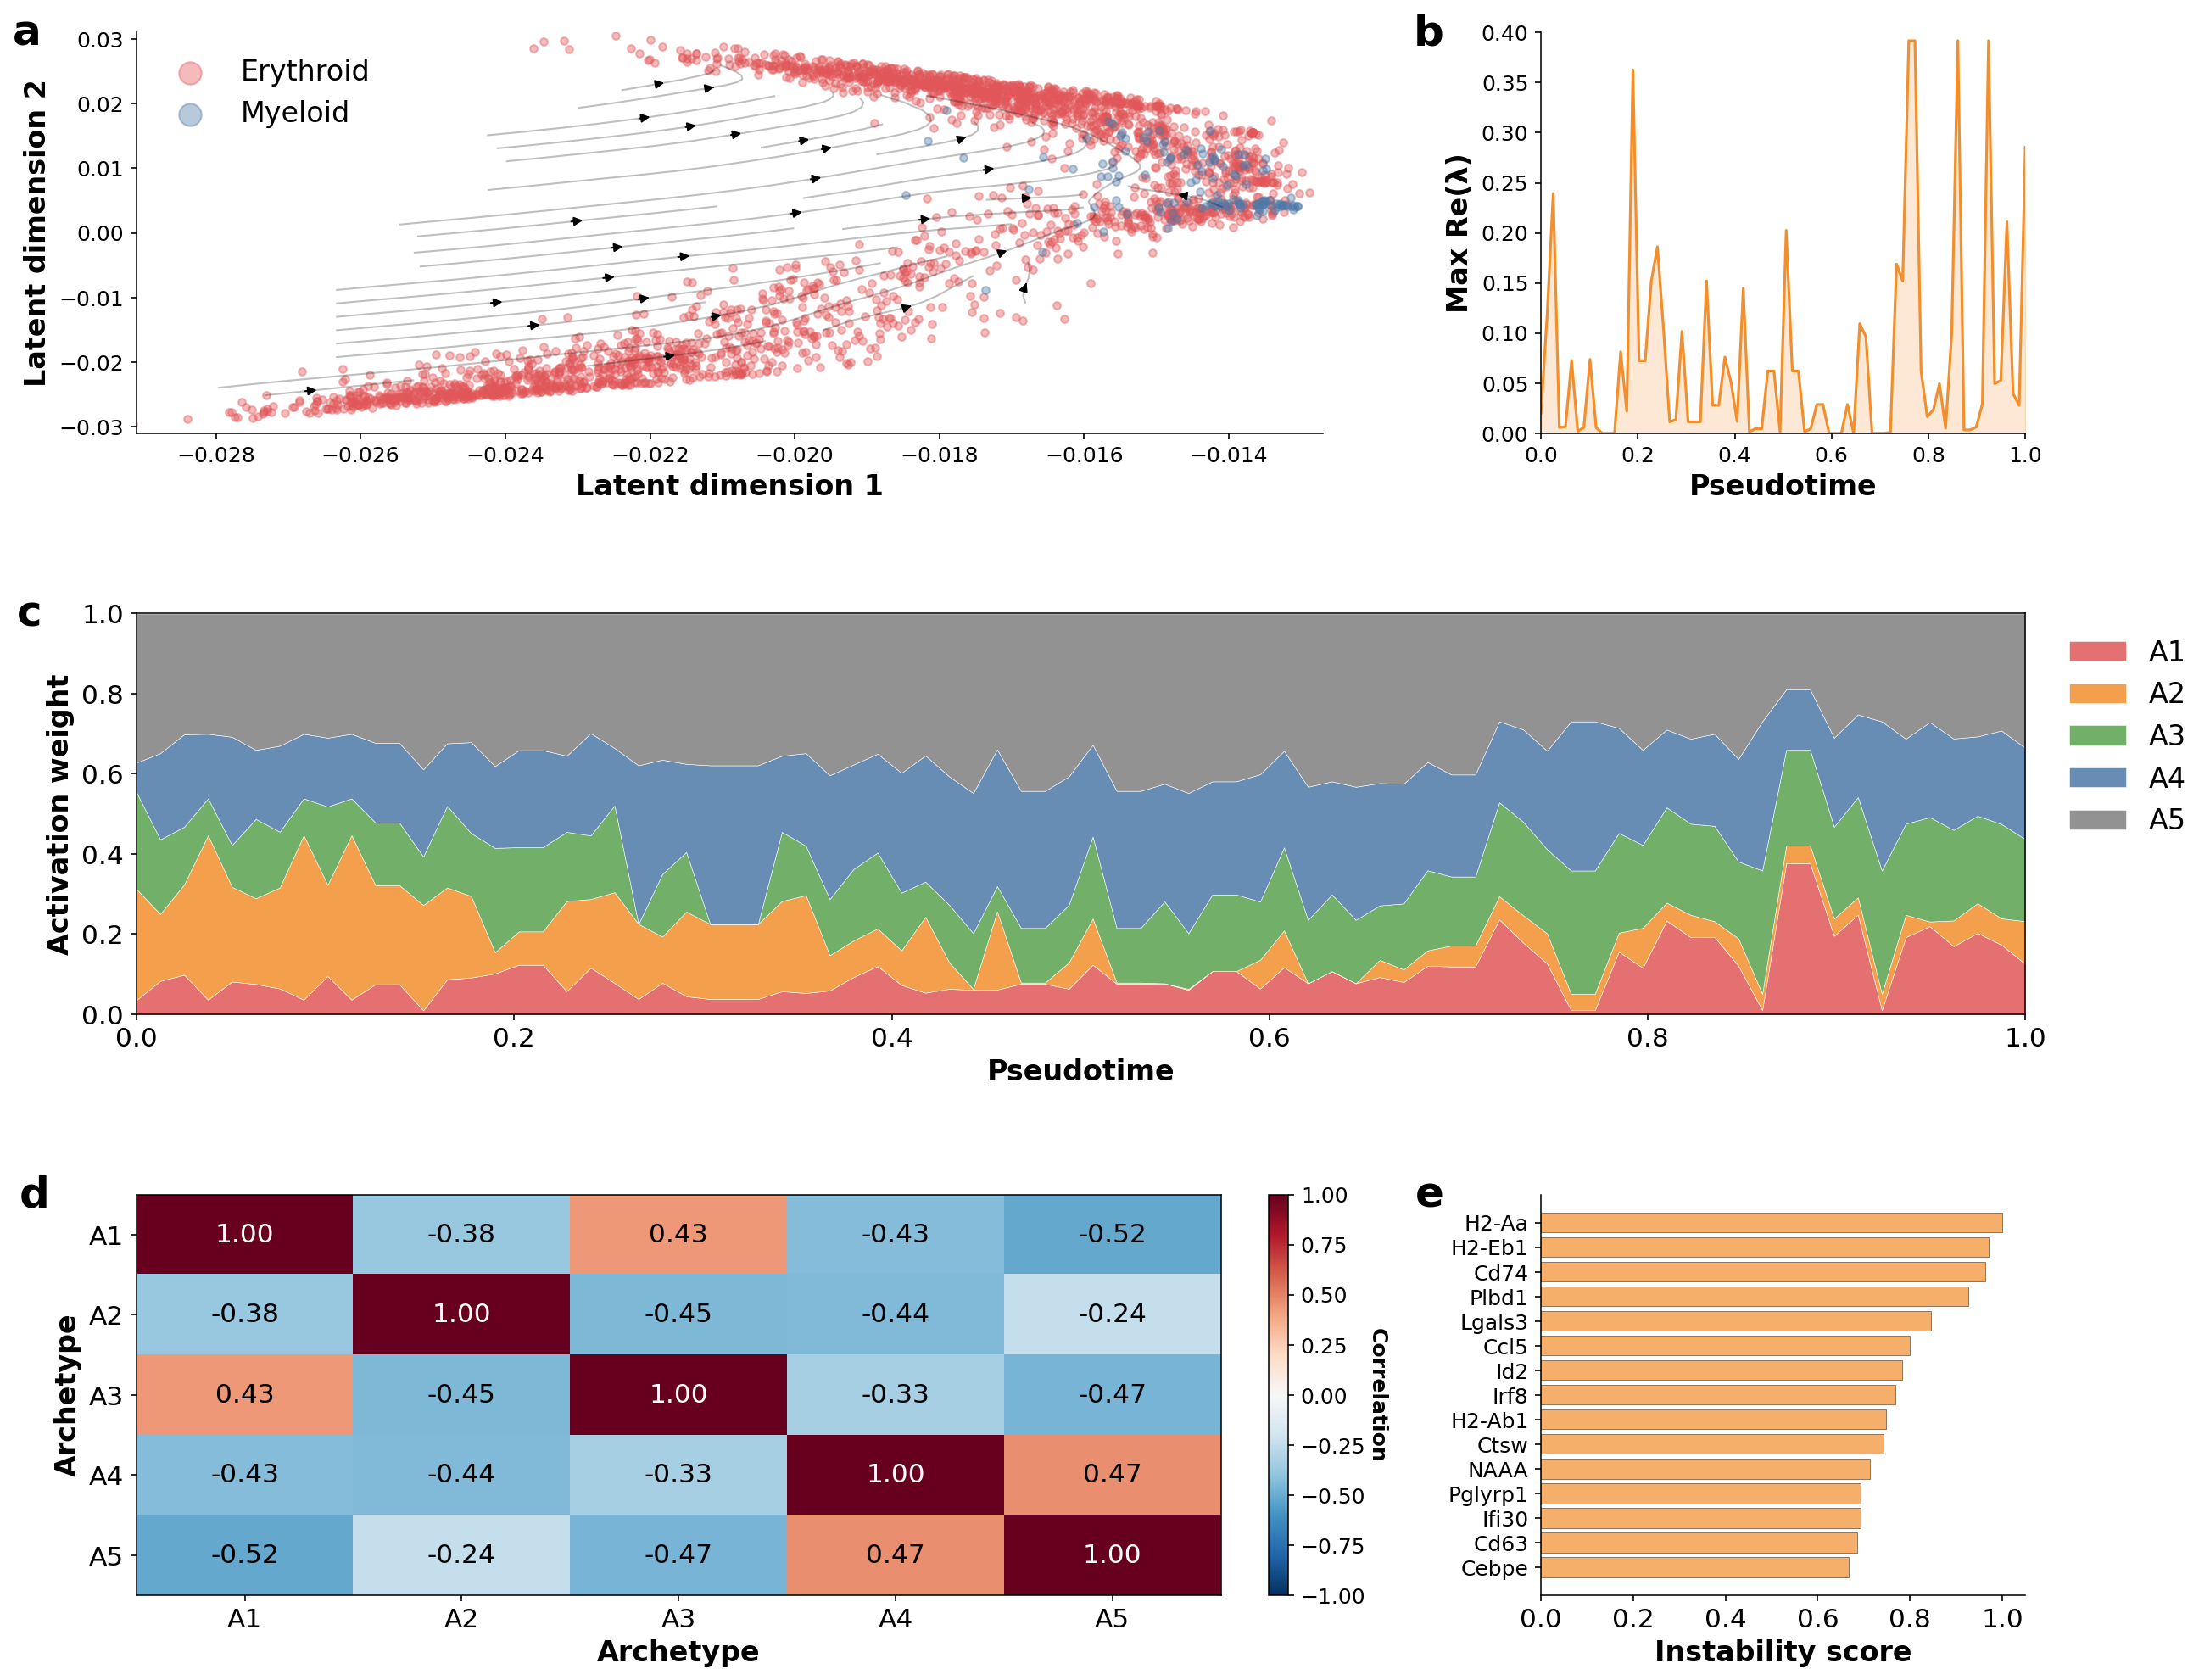

In [8]:
print('Generating Figure 4 without titles...')

# Color palette
COLORS = {
    'erythroid': '#E15759',
    'myeloid': '#4E79A7',
    'branch': '#F28E2B',
    'archetype1': '#E15759',
    'archetype2': '#F28E2B',
    'archetype3': '#59A14F',
    'archetype4': '#4E79A7',
    'archetype5': '#7F7F7F'
}

# Create figure
fig = plt.figure(figsize=(16.5, 13.5))
gs = GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.45,
              left=0.07, right=0.97, top=0.96, bottom=0.05)

# Panel a: Drift field
ax_a = fig.add_subplot(gs[0, :2])
for lin in ['Erythroid', 'Myeloid']:
    mask = np.array(lineage) == lin
    color = COLORS['erythroid'] if lin == 'Erythroid' else COLORS['myeloid']
    ax_a.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=color, s=18, alpha=0.4, label=lin, rasterized=True)

# Add streamlines
n_grid = 15
x_min, x_max = X_pca[:, 0].min(), X_pca[:, 0].max()
y_min, y_max = X_pca[:, 1].min(), X_pca[:, 1].max()
x_grid = np.linspace(x_min, x_max, n_grid)
y_grid = np.linspace(y_min, y_max, n_grid)

U = griddata(X_pca[:, :2], drift[:, 0], (x_grid[None, :], y_grid[:, None]), method='linear')
V = griddata(X_pca[:, :2], drift[:, 1], (x_grid[None, :], y_grid[:, None]), method='linear')

strm = ax_a.streamplot(x_grid, y_grid, U, V, color='black', linewidth=1, density=1.0)
strm.lines.set_alpha(0.25)

ax_a.set_xlabel('Latent dimension 1', fontsize=16, fontweight='bold')
ax_a.set_ylabel('Latent dimension 2', fontsize=16, fontweight='bold')
ax_a.set_xlim(-0.0291, -0.0127) 
ax_a.set_ylim(-0.031, 0.031)
ax_a.tick_params(axis='both', labelsize=12)
ax_a.legend(frameon=False, fontsize=16, markerscale=3) 
ax_a.spines['top'].set_visible(False)
ax_a.spines['right'].set_visible(False)

# Panel b: Instability
ax_b = fig.add_subplot(gs[0, 2])
ax_b.plot(time_points, instability, color=COLORS['branch'], linewidth=1.5)
ax_b.fill_between(time_points, 0, instability, alpha=0.2, color=COLORS['branch'])
ax_b.set_xlabel('Pseudotime', fontsize=16, fontweight='bold')
ax_b.set_ylabel('Max Re(λ)', fontsize=16, fontweight='bold')
ax_b.set_xlim(0, 1)
ax_b.set_ylim(0, 0.4)
ax_b.tick_params(axis='both', labelsize=12)
ax_b.spines['top'].set_visible(False)
ax_b.spines['right'].set_visible(False)

# Panel c: Archetype activations
ax_c = fig.add_subplot(gs[1, :])
colors = [COLORS[f'archetype{i+1}'] for i in range(n_archetypes)]
ax_c.stackplot(time_points, activations.T, 
              labels=[f'A{i+1}' for i in range(n_archetypes)],
              colors=colors, alpha=0.85, linewidth=0.3, edgecolor='white')
ax_c.set_xlabel('Pseudotime', fontsize=16, fontweight='bold')
ax_c.set_ylabel('Activation weight', fontsize=16, fontweight='bold')
ax_c.legend(loc='upper left', bbox_to_anchor=(1.01, 1), frameon=False, fontsize=16)
ax_c.set_xlim(time_points.min(), time_points.max())
ax_c.set_ylim([0, 1])
ax_c.tick_params(axis='both', labelsize=15)
ax_c.spines['top'].set_visible(True)
ax_c.spines['right'].set_visible(True)

# Panel d: Correlation matrix
ax_d = fig.add_subplot(gs[2, :2])
im = ax_d.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
cbar = plt.colorbar(im, ax=ax_d, fraction=0.046, pad=0.04)
cbar.set_label('Correlation', rotation=270, labelpad=12, fontsize=12, fontweight='bold')
cbar.ax.tick_params(labelsize=12)

ax_d.set_xticks(range(n_archetypes))
ax_d.set_yticks(range(n_archetypes))
ax_d.set_xticklabels([f'A{i+1}' for i in range(n_archetypes)], fontsize=15)
ax_d.set_yticklabels([f'A{i+1}' for i in range(n_archetypes)], fontsize=15)

for i in range(n_archetypes):
    for j in range(n_archetypes):
        color = 'white' if abs(corr_matrix[i, j]) > 0.6 else 'black'
        ax_d.text(j, i, f'{corr_matrix[i, j]:.2f}',
                 ha="center", va="center", color=color, fontsize=15)

ax_d.set_xlabel('Archetype', fontsize=16, fontweight='bold')
ax_d.set_ylabel('Archetype', fontsize=16, fontweight='bold')

# Panel e: Gene rankings
ax_e = fig.add_subplot(gs[2, 2])
top_genes = gene_ranking.head(15)
y_pos = np.arange(len(top_genes))
ax_e.barh(y_pos, top_genes['instability_score'], color=COLORS['branch'],
         alpha=0.7, edgecolor='black', linewidth=0.3)
ax_e.set_yticks(y_pos)
ax_e.set_yticklabels(top_genes['gene'], fontsize=12)
ax_e.invert_yaxis()
ax_e.set_xlabel('Instability score', fontsize=16, fontweight='bold')
ax_e.tick_params(axis='x', labelsize=15)
ax_e.spines['top'].set_visible(False)
ax_e.spines['right'].set_visible(False)

ax_a.text(-0.08, 1.05, 'a', transform=ax_a.transAxes,
             fontsize=24, fontweight='bold', va='top', ha='right')
ax_b.text(-0.20, 1.05, 'b', transform=ax_b.transAxes,
             fontsize=24, fontweight='bold', va='top', ha='right')
ax_c.text(-0.05, 1.05, 'c', transform=ax_c.transAxes,
             fontsize=24, fontweight='bold', va='top', ha='right')
ax_d.text(-0.08, 1.05, 'd', transform=ax_d.transAxes,
             fontsize=24, fontweight='bold', va='top', ha='right')
ax_e.text(-0.20, 1.05, 'e', transform=ax_e.transAxes,
             fontsize=24, fontweight='bold', va='top', ha='right')

# Save figure
output_png = '../Figures/Figure4_scIDiff_noTitle.png'
output_pdf = '../Figures/Figure4_scIDiff_noTitle.pdf'
plt.savefig(output_png, dpi=600, bbox_inches='tight')
plt.savefig(output_pdf, dpi=600, bbox_inches='tight')

print(f'\n✓ Figure 4 saved:')
print(f'  PNG: {output_png}')
print(f'  PDF: {output_pdf}')

plt.show()

## Step 8: Save Results

Export gene rankings and analysis results.

In [9]:
# Save gene rankings
gene_ranking.to_csv('gene_rankings.csv', index=False)

# Save Jacobians and archetypes
np.savez('analysis_results.npz',
         jacobians=jacobians,
         eigenvalues=eigenvalues,
         time_points=time_points,
         instability=instability,
         activations=activations,
         patterns=patterns,
         correlation=corr_matrix)

print('✓ Results saved:')
print('  - gene_rankings.csv')
print('  - analysis_results.npz')
print('\n Analysis complete!')

✓ Results saved:
  - gene_rankings.csv
  - analysis_results.npz

 Analysis complete!
